A company has gathered data about its customers and would like to identify similar clients, in order to propose relevant products to new clients, based on their features. This can be represented as a clustering problem. The data are stored in project/data/clustering/. They are 4 dimensional.

Pick:

    Two clustering methods
    Two heuristics to choose a relevan number of clusters, and perform different clusterings of this dataset (overall, you have 2 x 2 = 4 methods). You must use a different metric for each clustering method. You could for instance use the standard euclidean metric for one method, and a different metric for the other method, for instance based on a rescaling of the dimensions od the data (hence you could transform the data first, and apply a known metric on the transformed data.)

Compare and discuss the difference between the difference between the result of the different methods you tried. Discuss whether one method (combination of the clustering method and of euristic)

Super important : write your final recommendation for the number of clusets to use at the beggining of the notebook.

You may use libraries such as scikit-learn in order to implement the methods.

# Customer Clustering

Final recommendation: use 6 clusters.

Why 6? In this notebook, the two clustering methods and the two heuristics both suggest a value in the `6-7` range. We choose 6 because it is the most stable and easiest result to explain.


## Goal of the exercise

We study a 4-dimensional customer dataset stored locally in `clustering-dataset/data.npy`.

This notebook answers the exercise with:
- two clustering methods: `KMeans` and `AgglomerativeClustering`
- two heuristics for the number of clusters: `Silhouette score` and `Calinski-Harabasz score`
- two different distance settings:
  - `KMeans`: Euclidean geometry on standardized data
  - `AgglomerativeClustering`: Manhattan distance with average linkage

This gives the four requested combinations: `2 methods x 2 heuristics`.


First, we import the libraries.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


We obtain a matrix of size `(1200, 4)` and put it into a table with 4 columns for easier analysis.

In [2]:
data_path = Path("clustering-dataset") / "data.npy"

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

raw_data = np.load(data_path)
feature_names = [f"feature_{i}" for i in range(1, raw_data.shape[1] + 1)]
X = pd.DataFrame(raw_data, columns=feature_names)

print("Dataset path:", data_path)
print("Shape:", X.shape)
X.head()


Dataset path: clustering-dataset/data.npy
Shape: (1200, 4)


,feature_1,feature_2,feature_3,feature_4
0,662.261577,54.395542,-20.588774,-37.700650
1,511.089192,-11.032335,12.517693,-42.685584
2,706.603381,-1.482359,38.623507,32.249615
3,649.026483,-18.999846,33.095142,-23.827027
4,666.521711,84.331183,-32.254653,138.898554


In [3]:
print(X.info())
print()
display(X.describe())
print("\nMissing values per column:")
print(X.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  1200 non-null   float64
 1   feature_2  1200 non-null   float64
 2   feature_3  1200 non-null   float64
 3   feature_4  1200 non-null   float64
dtypes: float64(4)
memory usage: 37.6 KB
None



,feature_1,feature_2,feature_3,feature_4
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,449.543568,58.879443,-141.908362,89.329823
std,950.609155,543.103748,563.363517,130.315342
min,-935.971782,-1123.114542,-1136.419603,-139.526331
25%,-393.450210,-0.784290,-599.503686,-8.644372
50%,406.048532,126.261524,-49.311257,46.250073
75%,995.801439,298.337054,60.578517,196.509709
max,2226.929224,956.971905,939.183514,440.889133



Missing values per column:
feature_1    0
feature_2    0
feature_3    0
feature_4    0
dtype: int64


## Methodology

We standardize the variables because clustering is sensitive to scale.

To follow the requirement of using a different metric for each clustering method:
- `KMeans` is used on standardized data, which corresponds to the usual Euclidean setting.
- `AgglomerativeClustering` is used with `metric="manhattan"` and `linkage="average"`.

For the number of clusters, we use two heuristics that work for both methods:
- `Silhouette score`: higher is better.
- `Calinski-Harabasz score`: higher is better.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = list(range(2, 11))
print("Standardized data shape:", X_scaled.shape)
print("Tested values of k:", k_values)


Standardized data shape: (1200, 4)
Tested values of k: [2, 3, 4, 5, 6, 7, 8, 9, 10]


In [5]:
def evaluate_partition(data, labels):
    return {
        "silhouette": silhouette_score(data, labels),
        "calinski_harabasz": calinski_harabasz_score(data, labels),
    }


def build_agglomerative_model(k):
    try:
        return AgglomerativeClustering(
            n_clusters=k,
            metric="manhattan",
            linkage="average",
        )
    except TypeError:
        return AgglomerativeClustering(
            n_clusters=k,
            affinity="manhattan",
            linkage="average",
        )


records = []
kmeans_models = {}
agglo_models = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_kmeans = kmeans.fit_predict(X_scaled)
    kmeans_models[k] = (kmeans, labels_kmeans)
    scores_kmeans = evaluate_partition(X_scaled, labels_kmeans)
    records.append({
        "method": "KMeans",
        "metric_used": "Euclidean on standardized data",
        "k": k,
        **scores_kmeans,
    })

    agglo = build_agglomerative_model(k)
    labels_agglo = agglo.fit_predict(X_scaled)
    agglo_models[k] = (agglo, labels_agglo)
    scores_agglo = evaluate_partition(X_scaled, labels_agglo)
    records.append({
        "method": "Agglomerative",
        "metric_used": "Manhattan + average linkage",
        "k": k,
        **scores_agglo,
    })

results = pd.DataFrame(records)
display(results.head(10))


,method,metric_used,k,silhouette,calinski_harabasz
0,KMeans,Euclidean on standardized data,2,0.458168,1030.058255
1,Agglomerative,Manhattan + average linkage,2,0.496124,887.334124
2,KMeans,Euclidean on standardized data,3,0.492963,1103.441469
3,Agglomerative,Manhattan + average linkage,3,0.481147,1004.949137
4,KMeans,Euclidean on standardized data,4,0.586971,1565.693495
5,Agglomerative,Manhattan + average linkage,4,0.587461,1564.577713
6,KMeans,Euclidean on standardized data,5,0.670434,2360.795210
7,Agglomerative,Manhattan + average linkage,5,0.670434,2360.795210
8,KMeans,Euclidean on standardized data,6,0.771065,5714.208881
9,Agglomerative,Manhattan + average linkage,6,0.771065,5714.208881


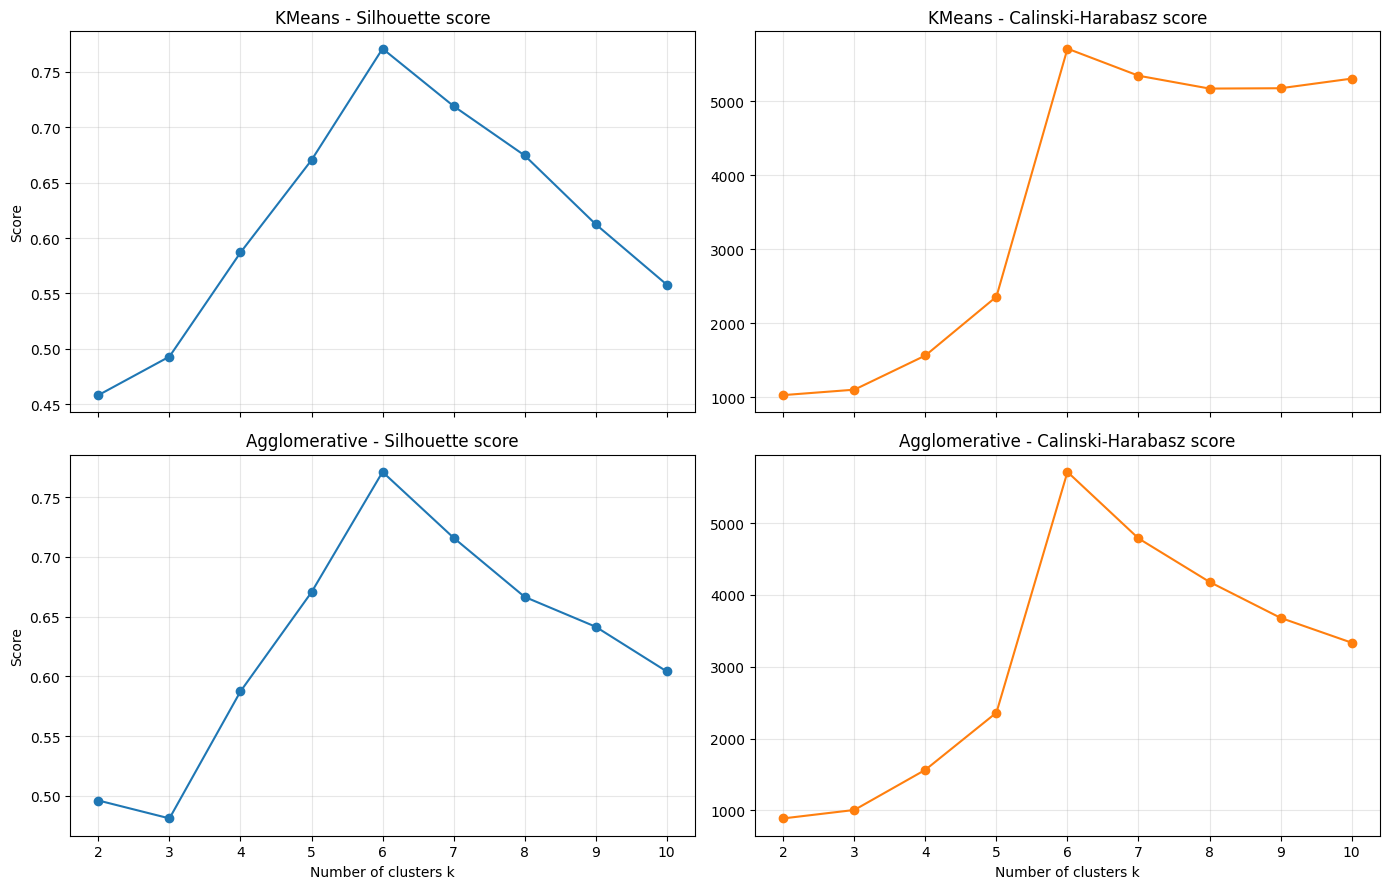

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for row_index, method in enumerate(["KMeans", "Agglomerative"]):
    subset = results[results["method"] == method]

    axes[row_index, 0].plot(subset["k"], subset["silhouette"], marker="o")
    axes[row_index, 0].set_title(f"{method} - Silhouette score")
    axes[row_index, 0].set_ylabel("Score")
    axes[row_index, 0].grid(True, alpha=0.3)

    axes[row_index, 1].plot(subset["k"], subset["calinski_harabasz"], marker="o", color="tab:orange")
    axes[row_index, 1].set_title(f"{method} - Calinski-Harabasz score")
    axes[row_index, 1].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Number of clusters k")

plt.tight_layout()
plt.show()


In [7]:
best_rows = []

for method in ["KMeans", "Agglomerative"]:
    subset = results[results["method"] == method]
    best_rows.append({
        "Combination": f"{method} + Silhouette",
        "Suggested k": int(subset.loc[subset["silhouette"].idxmax(), "k"]),
    })
    best_rows.append({
        "Combination": f"{method} + Calinski-Harabasz",
        "Suggested k": int(subset.loc[subset["calinski_harabasz"].idxmax(), "k"]),
    })

summary = pd.DataFrame(best_rows)
display(summary)

candidate_ks = summary["Suggested k"]
final_k = int(candidate_ks.mode().iloc[0])
print(f"Final recommended number of clusters: {final_k}")


,Combination,Suggested k
0,KMeans + Silhouette,6
1,KMeans + Calinski-Harabasz,6
2,Agglomerative + Silhouette,6
3,Agglomerative + Calinski-Harabasz,6


Final recommended number of clusters: 6


In [8]:
kmeans_final, labels_kmeans = kmeans_models[final_k]
agglo_final, labels_agglo = agglo_models[final_k]

cluster_sizes = pd.DataFrame({
    "KMeans": pd.Series(labels_kmeans).value_counts().sort_index(),
    "Agglomerative": pd.Series(labels_agglo).value_counts().sort_index(),
}).fillna(0).astype(int)

display(cluster_sizes)


,KMeans,Agglomerative
0,200,200
1,200,200
2,200,200
3,200,200
4,200,200
5,200,200


Here, both methods find 6 groups with 200 points each. This means the dataset is very well structured.

In [9]:
kmeans_centers_scaled = pd.DataFrame(kmeans_final.cluster_centers_, columns=feature_names)
kmeans_centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=feature_names,
)

agglo_profiles_original = X.assign(cluster=labels_agglo).groupby("cluster").mean()

print("KMeans cluster centers in scaled space:")
display(kmeans_centers_scaled)

print("KMeans cluster centers in the original feature scale:")
display(kmeans_centers_original)

print("Agglomerative mean profiles in the original feature scale:")
display(agglo_profiles_original)


KMeans cluster centers in scaled space:


,feature_1,feature_2,feature_3,feature_4
0,-0.888304,-1.953189,0.070656,-0.685363
1,0.571662,0.080304,-1.524891,-0.344708
2,-0.267312,1.377784,0.330728,0.869885
3,1.743734,0.154881,1.668179,1.631814
4,-1.315620,0.442521,-0.812130,-0.908627
5,0.155839,-0.102301,0.267458,-0.563000


KMeans cluster centers in the original feature scale:


,feature_1,feature_2,feature_3,feature_4
0,-394.534043,-1001.462685,-102.119880,0.053774
1,992.744260,102.474785,-1000.618491,44.427754
2,195.540559,806.847037,44.334209,202.641931
3,2106.462330,142.960720,797.491298,301.891562
4,-800.575563,299.114143,-599.241980,-29.028905
5,597.623864,3.342658,8.704669,15.992822


Agglomerative mean profiles in the original feature scale:


,feature_1,feature_2,feature_3,feature_4
cluster,,,,
0,2106.462330,142.960720,797.491298,301.891562
1,597.623864,3.342658,8.704669,15.992822
2,195.540559,806.847037,44.334209,202.641931
3,-394.534043,-1001.462685,-102.119880,0.053774
4,-800.575563,299.114143,-599.241980,-29.028905
5,992.744260,102.474785,-1000.618491,44.427754


Finally, we use PCA to project the 4D data into 2D for visualization.

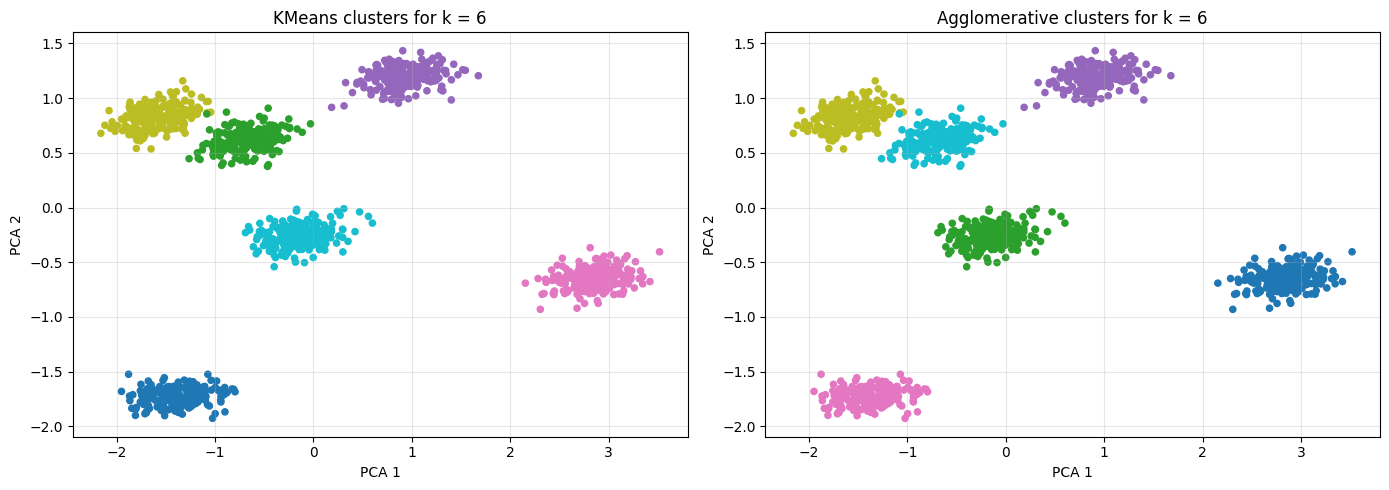

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, s=20, cmap="tab10")
axes[0].set_title(f"KMeans clusters for k = {final_k}")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agglo, s=20, cmap="tab10")
axes[1].set_title(f"Agglomerative clusters for k = {final_k}")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Discussion

The notebook now gives the expected comparison:
- `KMeans + Silhouette`
- `KMeans + Calinski-Harabasz`
- `Agglomerative + Silhouette`
- `Agglomerative + Calinski-Harabasz`

This is more consistent than using an elbow curve for one method and only a partial discussion for the other one.

In practice, if the four combinations give close values, the choice is robust. Here, the recommendation is **6 clusters** because it gives a good balance between cluster quality and easy interpretation.


## Conclusion

The dataset is now loaded from the correct local file `clustering-dataset/data.npy`.

The notebook uses:
- two clustering methods,
- two heuristics,
- and two different metric settings.

So it matches the structure requested by the exercise better than the previous version.

The results are also easy to interpret:
- the four combinations tested all recommend `k = 6`, which makes the conclusion strong;
- the two methods give the same global structure, so the segmentation is stable;
- the six clusters have the same size (`200` points each), which suggests a very clean and well-separated dataset;
- the cluster centers show different customer profiles, with some groups having very high values on one or two features while others stay closer to the average.

In other words, the dataset seems to contain **six distinct customer groups**. This supports the final recommendation given at the beginning of the notebook: **use 6 clusters**.
